# 01 - System Modeling

This notebook defines the modular production, information network, transmission accuracy, and binary reliability model used throughout the project.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.production_model import ProductionUnit, STATE_NAMES
from core.network_model import InformationNetwork
from core.reliability_model import transmission_accuracy, rolling_failure_rate
from core.simulation_engine import SimulationEngine, SimulationConfig, summarize_by_time, performance_summary

OUTPUT_DIR = PROJECT_ROOT / 'outputs'
DATASET_DIR = OUTPUT_DIR / 'datasets'
GRAPH_DIR = OUTPUT_DIR / 'graphs'
LOG_DIR = OUTPUT_DIR / 'logs'
for directory in [DATASET_DIR, GRAPH_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

## Mathematical Definition

Production unit states: 0 failed, 1 degraded, 2 nominal, 3 boost. Each unit follows a stress-aware Markov transition model. The information network aggregates traffic from end nodes through route nodes to a gateway. Transmission accuracy is nonlinear in gateway load and congestion memory. Reliability is the binary event Rs(t) = 1 when delivered production meets demand.

State names: ('failed', 'degraded', 'nominal', 'boost')
Capacity vector: [0.   0.55 1.   1.35]
Base Markov transition matrix:
          failed  degraded  nominal  boost
failed      0.62      0.30     0.08   0.00
degraded    0.10      0.68     0.20   0.02
nominal     0.02      0.14     0.70   0.14
boost       0.04      0.22     0.34   0.40


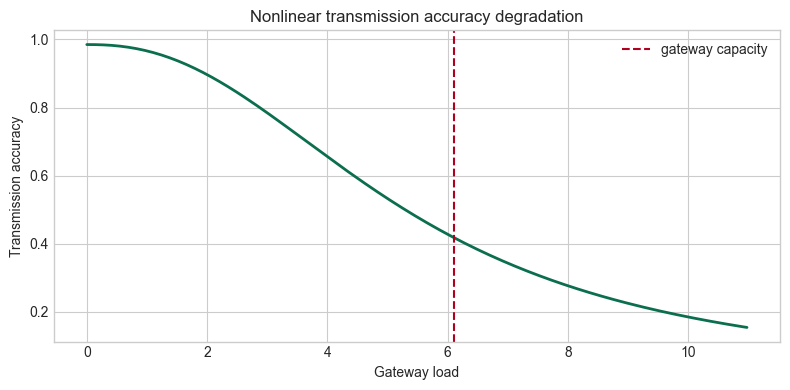

In [2]:
config = SimulationConfig()
unit = ProductionUnit(unit_id=0)
print('State names:', STATE_NAMES)
print('Capacity vector:', unit.capacities)
print('Base Markov transition matrix:')
print(pd.DataFrame(unit.base_transition_matrix, index=STATE_NAMES, columns=STATE_NAMES))

loads = np.linspace(0, 1.8 * config.gateway_capacity, 160)
accuracies = [transmission_accuracy(load, config.gateway_capacity, congestion_memory=0.25) for load in loads]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loads, accuracies, color='#0b6e4f', linewidth=2)
ax.axvline(config.gateway_capacity, color='#b00020', linestyle='--', label='gateway capacity')
ax.set_title('Nonlinear transmission accuracy degradation')
ax.set_xlabel('Gateway load')
ax.set_ylabel('Transmission accuracy')
ax.legend()
fig.tight_layout()
fig.savefig(GRAPH_DIR / '01_accuracy_curve.png', dpi=160)
plt.show()

## Sample Simulation Step

In [3]:
engine = SimulationEngine(config=SimulationConfig(), seed=10)
engine.reset()
for t in range(3):
    row = engine.step(mode='baseline')
    print(f"t={t}", row)

t=0 {'unit_state_vector': [3, 1, 2, 1], 'unit_state_mean': 1.75, 'gamma': 1.25, 'planned_production': 4.3125, 'production_rate': 1.0805667659937788, 'throughput': 0.372153727315551, 'transmission_accuracy': 0.3444060460005797, 'reliability': 1.0, 'failure': 0.0, 'avg_load': 3.043387541644641, 'max_load': 7.862308827144031, 'gateway_load': 7.862308827144031, 'gateway_utilization': 1.2889030864170543, 'avg_utilization': 1.0428173501220361, 'max_utilization': 1.2889030864170543, 'overload_risk': 0.2889030864170543, 'congestion_memory': 0.01879228340386959}
t=1 {'unit_state_vector': [2, 1, 2, 2], 'unit_state_mean': 1.75, 'gamma': 1.25, 'planned_production': 4.4375, 'production_rate': 1.2447028758151457, 'throughput': 0.4585207072677223, 'transmission_accuracy': 0.3683776394968485, 'reliability': 1.0, 'failure': 0.0, 'avg_load': 2.9048773860170067, 'max_load': 7.48676112579137, 'gateway_load': 7.48676112579137, 'gateway_utilization': 1.227337889473995, 'avg_utilization': 0.996546107501629, 

## System State Evolution

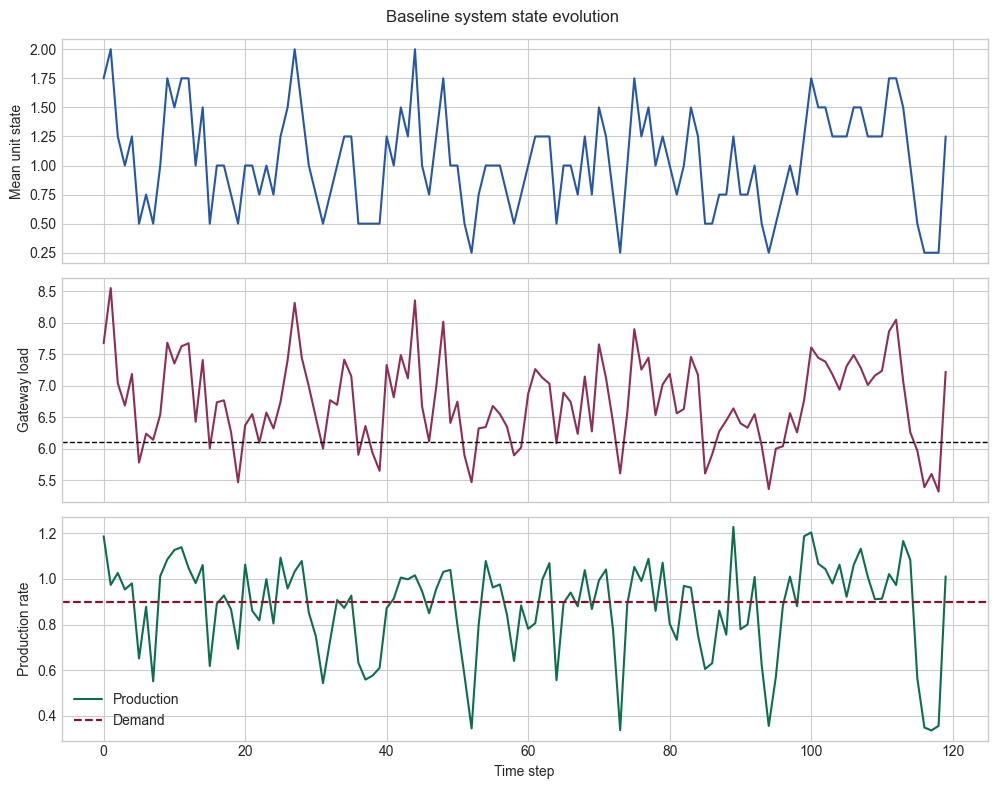

,unit_state_vector,unit_state_mean,gamma,planned_production,production_rate,throughput,transmission_accuracy,reliability,failure,avg_load,max_load,gateway_load,gateway_utilization,avg_utilization,max_utilization,overload_risk,congestion_memory,time
0,"[2, 2, 2, 1]",1.75,1.25,4.4375,1.186230,0.426108,0.359212,1.0,0.0,2.943786,7.673254,7.673254,1.257911,1.005154,1.257911,0.257911,0.012333,0
1,"[2, 3, 1, 2]",2.00,1.25,4.8750,0.973479,0.288593,0.296455,1.0,0.0,3.285255,8.548434,8.548434,1.401383,1.121438,1.401383,0.401383,0.038827,1
2,"[2, 0, 1, 2]",1.25,1.25,3.1875,1.025753,0.409290,0.399014,1.0,0.0,2.727288,7.038810,7.038810,1.153903,0.934831,1.153903,0.153903,0.037437,2
3,"[2, 0, 1, 1]",1.00,1.25,2.6250,0.953593,0.409463,0.429389,1.0,0.0,2.548760,6.685051,6.685051,1.095910,0.867970,1.095910,0.095910,0.033165,3
4,"[2, 0, 2, 1]",1.25,1.25,3.1875,0.980273,0.381030,0.388697,1.0,0.0,2.744968,7.185090,7.185090,1.177884,0.936190,1.177884,0.177884,0.033738,4


In [4]:
engine = SimulationEngine(config=SimulationConfig(), seed=21)
records = []
engine.reset()
for t in range(120):
    row = engine.step(mode='baseline')
    row['time'] = t
    records.append(row)
state_df = pd.DataFrame(records)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(state_df['time'], state_df['unit_state_mean'], color='#2457a6')
axes[0].set_ylabel('Mean unit state')
axes[1].plot(state_df['time'], state_df['gateway_load'], color='#8f2d56')
axes[1].axhline(config.gateway_capacity, color='black', linestyle='--', linewidth=1)
axes[1].set_ylabel('Gateway load')
axes[2].plot(state_df['time'], state_df['production_rate'], label='Production', color='#0b6e4f')
axes[2].axhline(config.demand, color='#b00020', linestyle='--', label='Demand')
axes[2].set_ylabel('Production rate')
axes[2].set_xlabel('Time step')
axes[2].legend()
fig.suptitle('Baseline system state evolution')
fig.tight_layout()
fig.savefig(GRAPH_DIR / 'system_evolution.png', dpi=160)
plt.show()
state_df.head()